# Analysis of Existing Sweep Data

Thorough analysis of the 216-row converged sweep before launching a new (expensive) sweep with full metrics.

Goals:
1. Predict all available metrics (not just nonlinear_gain) — linearity_score, mse_full, mse_linear
2. Metric correlations and redundancy analysis  
3. Convergence diagnostics — which configs didn't converge and what does that tell us?
4. Validate the analysis pipeline so we're confident in the setup for the full sweep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_score
from scipy.optimize import curve_fit
from scipy import stats

df = pd.read_csv('metric_prediction_data_converged.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nConverged: {df['converged'].sum()}/{len(df)} ({df['converged'].mean():.1%})")
print(f"\nDescriptive stats:")
df[['nonlinear_gain', 'linearity_score', 'mse_full', 'mse_linear', 'gain_std', 'steps_used']].describe()

Shape: (216, 14)

Columns: ['n', 'm', 'l', 'S', 'nonlinear_gain', 'linearity_score', 'mse_full', 'mse_linear', 'gain_mean', 'gain_std', 'steps_used', 'steps_mean', 'converged', 'n_converged']

Converged: 107/216 (49.5%)

Descriptive stats:


,nonlinear_gain,linearity_score,mse_full,mse_linear,gain_std,steps_used
count,2.160000e+02,216.000000,216.000000,216.000000,216.000000,216.000000
mean,2.925789e-01,0.872097,0.014641,0.027950,0.038614,54341.458333
std,2.793974e-01,0.137190,0.010814,0.029171,0.049833,30450.213536
min,-5.063758e-04,0.402319,0.000363,0.000363,0.000000,20000.000000
25%,7.261176e-08,0.758546,0.005833,0.008495,0.000012,20000.000000
50%,2.531599e-01,0.923500,0.011741,0.018962,0.021437,50000.000000
75%,5.151849e-01,0.999999,0.022275,0.038280,0.054743,70710.000000
max,9.088166e-01,1.000000,0.043076,0.216432,0.303022,141421.000000


## 1. Derived features and data enrichment

In [2]:
# Derived features
df['compression'] = df['n'] / df['m']
df['apd'] = (1 - df['S']) * df['n'] / df['m']  # active per dim
df['log_compression'] = np.log2(df['compression'])
df['log_n'] = np.log2(df['n'])
df['log_m'] = np.log2(df['m'])
df['is_deep'] = (df['l'] > 1).astype(int)
df['mse_ratio'] = df['mse_full'] / (df['mse_linear'] + 1e-10)  # <1 means nonlinear helps
df['log_mse_full'] = np.log10(df['mse_full'] + 1e-10)
df['log_mse_linear'] = np.log10(df['mse_linear'] + 1e-10)

# Separate l=1 (always linear) from l>1
df_deep = df[df['l'] > 1].copy().reset_index(drop=True)
df_linear = df[df['l'] == 1].copy().reset_index(drop=True)

print(f"l=1 (linear baseline): {len(df_linear)} configs")
print(f"l>1 (potentially nonlinear): {len(df_deep)} configs")
print(f"\nl=1 gain stats: mean={df_linear['nonlinear_gain'].mean():.6f}, max={df_linear['nonlinear_gain'].max():.6f}")
print(f"l>1 gain stats: mean={df_deep['nonlinear_gain'].mean():.4f}, std={df_deep['nonlinear_gain'].std():.4f}")

l=1 (linear baseline): 54 configs
l>1 (potentially nonlinear): 162 configs

l=1 gain stats: mean=0.000000, max=0.000000
l>1 gain stats: mean=0.3901, std=0.2568


## 2. Metric correlations and redundancy

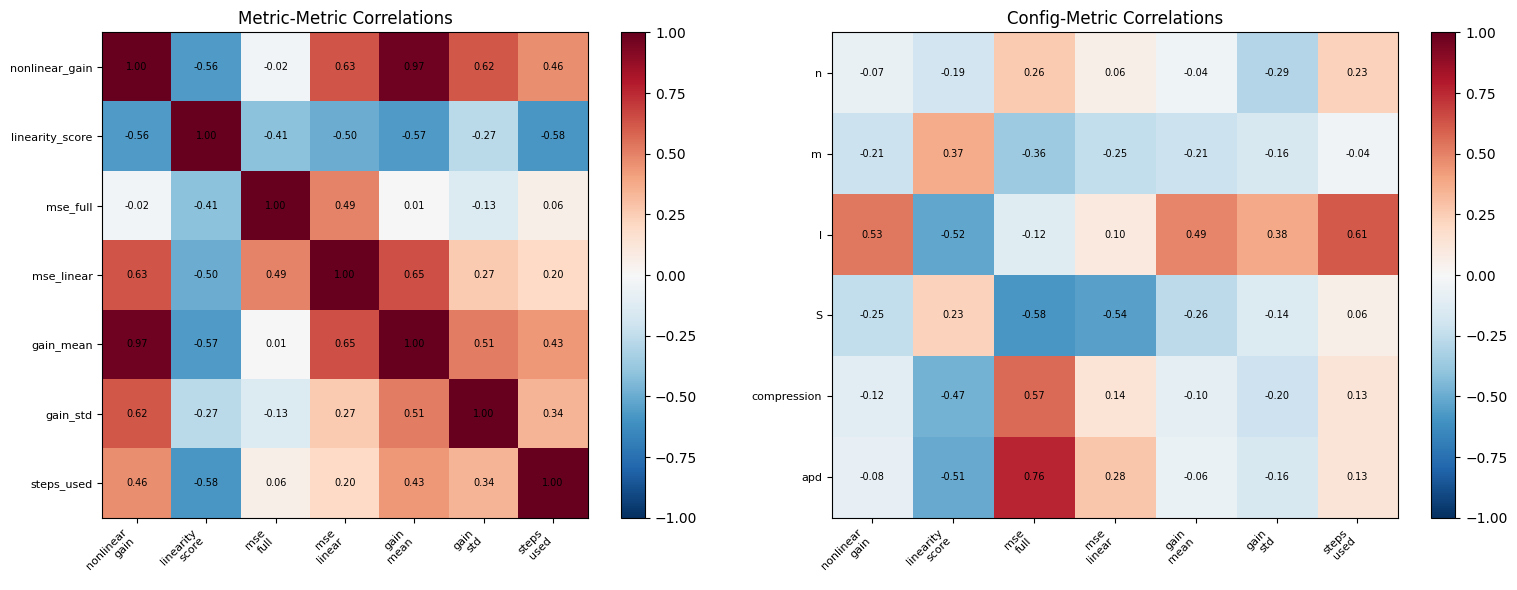


Key correlations:
  nonlinear_gain ↔ linearity_score: -0.564
  nonlinear_gain ↔ mse_ratio: -1.000
  mse_full ↔ mse_linear: 0.492
  gain_mean ↔ nonlinear_gain: 0.973


In [3]:
# Correlation matrix of all numeric columns
metric_cols = ['nonlinear_gain', 'linearity_score', 'mse_full', 'mse_linear', 
               'gain_mean', 'gain_std', 'steps_used']
config_cols = ['n', 'm', 'l', 'S', 'compression', 'apd']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics vs metrics
corr_metrics = df[metric_cols].corr()
im = axes[0].imshow(corr_metrics, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(metric_cols)))
axes[0].set_yticks(range(len(metric_cols)))
axes[0].set_xticklabels([c.replace('_', '\n') for c in metric_cols], fontsize=8, rotation=45, ha='right')
axes[0].set_yticklabels(metric_cols, fontsize=8)
for i in range(len(metric_cols)):
    for j in range(len(metric_cols)):
        axes[0].text(j, i, f'{corr_metrics.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
axes[0].set_title('Metric-Metric Correlations')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Config vs metrics
corr_config = df[config_cols + metric_cols].corr().loc[config_cols, metric_cols]
im2 = axes[1].imshow(corr_config, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(metric_cols)))
axes[1].set_yticks(range(len(config_cols)))
axes[1].set_xticklabels([c.replace('_', '\n') for c in metric_cols], fontsize=8, rotation=45, ha='right')
axes[1].set_yticklabels(config_cols, fontsize=8)
for i in range(len(config_cols)):
    for j in range(len(metric_cols)):
        axes[1].text(j, i, f'{corr_config.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
axes[1].set_title('Config-Metric Correlations')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"  nonlinear_gain ↔ linearity_score: {df['nonlinear_gain'].corr(df['linearity_score']):.3f}")
print(f"  nonlinear_gain ↔ mse_ratio: {df['nonlinear_gain'].corr(df['mse_ratio']):.3f}")
print(f"  mse_full ↔ mse_linear: {df['mse_full'].corr(df['mse_linear']):.3f}")
print(f"  gain_mean ↔ nonlinear_gain: {df['gain_mean'].corr(df['nonlinear_gain']):.3f}")

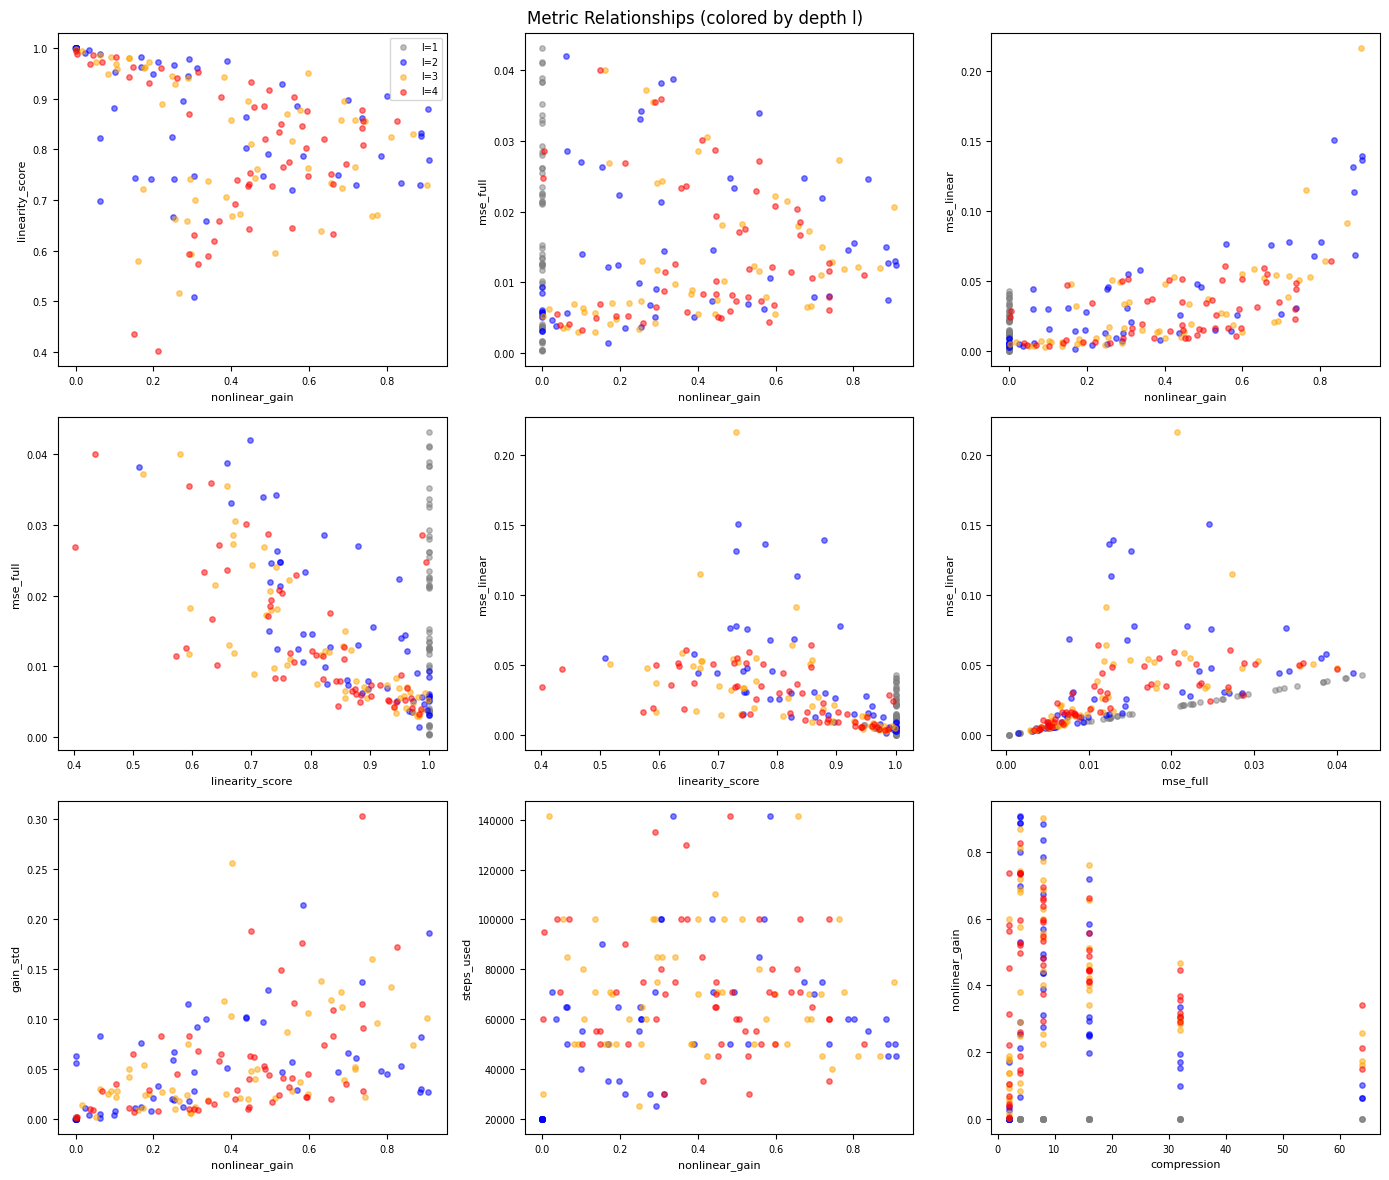

In [4]:
# Scatter matrix of key metrics (colored by l)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
pairs = [
    ('nonlinear_gain', 'linearity_score'),
    ('nonlinear_gain', 'mse_full'),
    ('nonlinear_gain', 'mse_linear'),
    ('linearity_score', 'mse_full'),
    ('linearity_score', 'mse_linear'),
    ('mse_full', 'mse_linear'),
    ('nonlinear_gain', 'gain_std'),
    ('nonlinear_gain', 'steps_used'),
    ('compression', 'nonlinear_gain'),
]

colors = {1: 'gray', 2: 'blue', 3: 'orange', 4: 'red'}
for ax, (x_col, y_col) in zip(axes.flat, pairs):
    for l_val in sorted(df['l'].unique()):
        sub = df[df['l'] == l_val]
        ax.scatter(sub[x_col], sub[y_col], c=colors[l_val], alpha=0.5, s=15, label=f'l={l_val}')
    ax.set_xlabel(x_col, fontsize=8)
    ax.set_ylabel(y_col, fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7)
plt.suptitle('Metric Relationships (colored by depth l)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Convergence diagnostics

In [5]:
# Which configs failed to converge?
not_converged = df[~df['converged']].copy()
print(f"Not converged: {len(not_converged)}/{len(df)}")
print(f"\nBy l:")
for l_val in sorted(df['l'].unique()):
    sub = df[df['l'] == l_val]
    nc = sub[~sub['converged']]
    print(f"  l={l_val}: {len(nc)}/{len(sub)} not converged ({len(nc)/len(sub):.0%})")

print(f"\nBy n (l>1 only):")
for n_val in sorted(df_deep['n'].unique()):
    sub = df_deep[df_deep['n'] == n_val]
    nc = sub[~sub['converged']]
    print(f"  n={n_val:4d}: {len(nc)}/{len(sub)} not converged ({len(nc)/len(sub):.0%})")

print(f"\nBy m (l>1 only):")
for m_val in sorted(df_deep['m'].unique()):
    sub = df_deep[df_deep['m'] == m_val]
    nc = sub[~sub['converged']]
    print(f"  m={m_val:3d}: {len(nc)}/{len(sub)} not converged ({len(nc)/len(sub):.0%})")

# Are unconverged configs systematically different?
print(f"\nUnconverged (l>1) gain: {not_converged[not_converged['l']>1]['nonlinear_gain'].describe()}")
print(f"Converged (l>1) gain: {df_deep[df_deep['converged']]['nonlinear_gain'].describe()}")

Not converged: 109/216

By l:
  l=1: 54/54 not converged (100%)
  l=2: 14/54 not converged (26%)
  l=3: 21/54 not converged (39%)
  l=4: 20/54 not converged (37%)

By n (l>1 only):
  n=  16: 20/27 not converged (74%)
  n=  32: 15/36 not converged (42%)
  n=  64: 15/45 not converged (33%)
  n= 128: 5/54 not converged (9%)

By m (l>1 only):
  m=  2: 13/36 not converged (36%)
  m=  4: 17/36 not converged (47%)
  m=  8: 14/36 not converged (39%)
  m= 16: 8/27 not converged (30%)
  m= 32: 2/18 not converged (11%)
  m= 64: 1/9 not converged (11%)

Unconverged (l>1) gain: count    55.000000
mean      0.396907
std       0.223385
min       0.016994
25%       0.188643
50%       0.437329
75%       0.572471
max       0.827230
Name: nonlinear_gain, dtype: float64
Converged (l>1) gain: count    107.000000
mean       0.386609
std        0.273373
min       -0.000506
25%        0.170396
50%        0.315796
75%        0.594139
max        0.908817
Name: nonlinear_gain, dtype: float64


## 4. Predicting linearity_score

linearity_score = fraction of encoding variance explained by linear model. Should be highly related to nonlinear_gain but captures something slightly different (encoding space vs reconstruction space).

In [6]:
# Predict linearity_score for l>1 (l=1 is always ~1.0)
# First, transform: nonlinearity = 1 - linearity_score (more interpretable, 0=linear)
df_deep['nonlinearity'] = 1 - df_deep['linearity_score']

targets = {
    'nonlinear_gain': df_deep['nonlinear_gain'].values,
    'nonlinearity': df_deep['nonlinearity'].values,
    'log_mse_full': df_deep['log_mse_full'].values,
    'log_mse_linear': df_deep['log_mse_linear'].values,
}

features = ['n', 'm', 'l', 'S', 'compression', 'apd', 'log_n', 'log_m', 'log_compression']
X = df_deep[features].values

print("GB cross-validation R² for each target (l>1 only):\n")
gb_scores = {}
for name, y in targets.items():
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    scores = cross_val_score(gb, X, y, cv=5, scoring='r2')
    gb_scores[name] = scores
    print(f"  {name:20s}: R² = {scores.mean():.3f} ± {scores.std():.3f}")

print("\n\nRF cross-validation R²:\n")
for name, y in targets.items():
    rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"  {name:20s}: R² = {scores.mean():.3f} ± {scores.std():.3f}")

GB cross-validation R² for each target (l>1 only):

  nonlinear_gain      : R² = 0.645 ± 0.071


  nonlinearity        : R² = 0.754 ± 0.117
  log_mse_full        : R² = 0.835 ± 0.113


  log_mse_linear      : R² = 0.861 ± 0.058


RF cross-validation R²:



  nonlinear_gain      : R² = 0.619 ± 0.099


  nonlinearity        : R² = 0.757 ± 0.044


  log_mse_full        : R² = 0.847 ± 0.121


  log_mse_linear      : R² = 0.874 ± 0.036


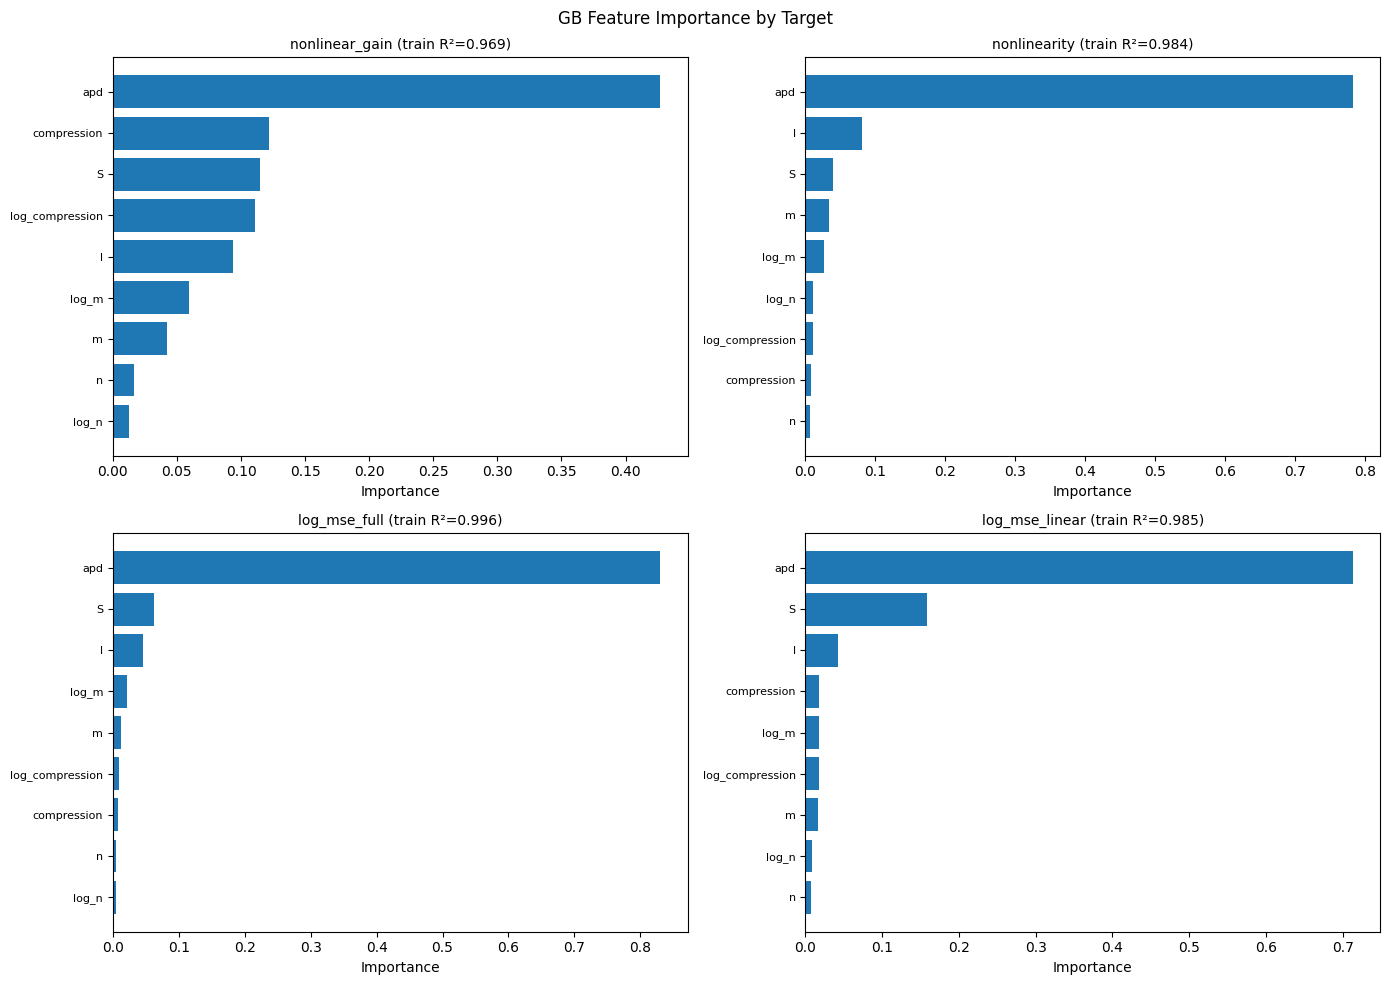

In [7]:
# Feature importance for each target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, y) in zip(axes.flat, targets.items()):
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    gb.fit(X, y)
    importances = gb.feature_importances_
    idx = np.argsort(importances)[::-1]
    ax.barh(range(len(features)), importances[idx])
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels([features[i] for i in idx], fontsize=8)
    ax.set_title(f'{name} (train R²={gb.score(X, y):.3f})', fontsize=10)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.suptitle('GB Feature Importance by Target', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Parametric forms for mse_full and mse_linear

These are log-scale targets, so we fit log(mse) = f(n, m, l, S). MSE should scale roughly as:
- Proportional to feature density (1-S) — more active features = more signal to compress
- Inverse in m — more bottleneck dims = less compression error
- Possibly log-linear in n — more input dims spreads signal

In [8]:
# Parametric form for log(mse_linear): should depend only on n, m, S (not l, since linear approx is l-independent)
# Theory: mse_linear ∝ (1-S) * n / m^α  (compression-limited)
# In log space: log(mse_linear) = a + b*log(n) + c*log(m) + d*log(1-S)

from sklearn.linear_model import LinearRegression

# Log-linear model for mse_linear
X_log = np.column_stack([
    np.log(df['n']),
    np.log(df['m']),
    np.log(1 - df['S']),
    df['l'],
])

y_log_linear = np.log(df['mse_linear'] + 1e-10)
y_log_full = np.log(df['mse_full'] + 1e-10)

# mse_linear should be l-independent
reg_linear = LinearRegression().fit(X_log, y_log_linear)
print("log(mse_linear) = a + b*log(n) + c*log(m) + d*log(1-S) + e*l")
print(f"  a={reg_linear.intercept_:.3f}, b(n)={reg_linear.coef_[0]:.3f}, c(m)={reg_linear.coef_[1]:.3f}, "
      f"d(1-S)={reg_linear.coef_[2]:.3f}, e(l)={reg_linear.coef_[3]:.3f}")
print(f"  R² = {reg_linear.score(X_log, y_log_linear):.4f}")

# mse_full should depend on l
reg_full = LinearRegression().fit(X_log, y_log_full)
print(f"\nlog(mse_full) = a + b*log(n) + c*log(m) + d*log(1-S) + e*l")
print(f"  a={reg_full.intercept_:.3f}, b(n)={reg_full.coef_[0]:.3f}, c(m)={reg_full.coef_[1]:.3f}, "
      f"d(1-S)={reg_full.coef_[2]:.3f}, e(l)={reg_full.coef_[3]:.3f}")
print(f"  R² = {reg_full.score(X_log, y_log_full):.4f}")

# Check: is mse_linear actually l-independent?
print(f"\nmse_linear by l:")
for l_val in sorted(df['l'].unique()):
    sub = df[df['l'] == l_val]
    print(f"  l={l_val}: mean={sub['mse_linear'].mean():.5f}, std={sub['mse_linear'].std():.5f}")

log(mse_linear) = a + b*log(n) + c*log(m) + d*log(1-S) + e*l
  a=-2.136, b(n)=0.539, c(m)=-0.608, d(1-S)=1.421, e(l)=0.206
  R² = 0.6677

log(mse_full) = a + b*log(n) + c*log(m) + d*log(1-S) + e*l
  a=-3.201, b(n)=0.587, c(m)=-0.603, d(1-S)=1.058, e(l)=0.018
  R² = 0.7547

mse_linear by l:
  l=1: mean=0.01720, std=0.01296
  l=2: mean=0.03622, std=0.03893
  l=3: mean=0.03123, std=0.03524
  l=4: mean=0.02715, std=0.01810


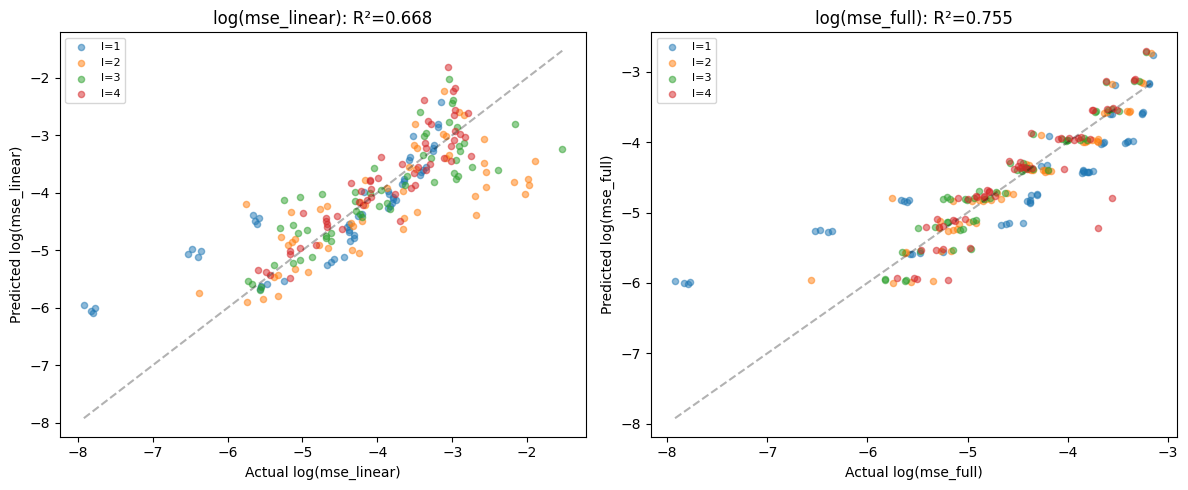

In [9]:
# Actual vs predicted for log(mse) models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y, reg) in zip(axes, [
    ('mse_linear', y_log_linear, reg_linear),
    ('mse_full', y_log_full, reg_full),
]):
    y_pred = reg.predict(X_log)
    for l_val in sorted(df['l'].unique()):
        mask = df['l'] == l_val
        ax.scatter(y[mask], y_pred[mask], alpha=0.5, s=20, label=f'l={l_val}')
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', alpha=0.3)
    ax.set_xlabel(f'Actual log({name})')
    ax.set_ylabel(f'Predicted log({name})')
    ax.set_title(f'log({name}): R²={reg.score(X_log, y):.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Phase diagrams for all metrics

Visualize each metric as a function of (compression, l) averaged over S and n.

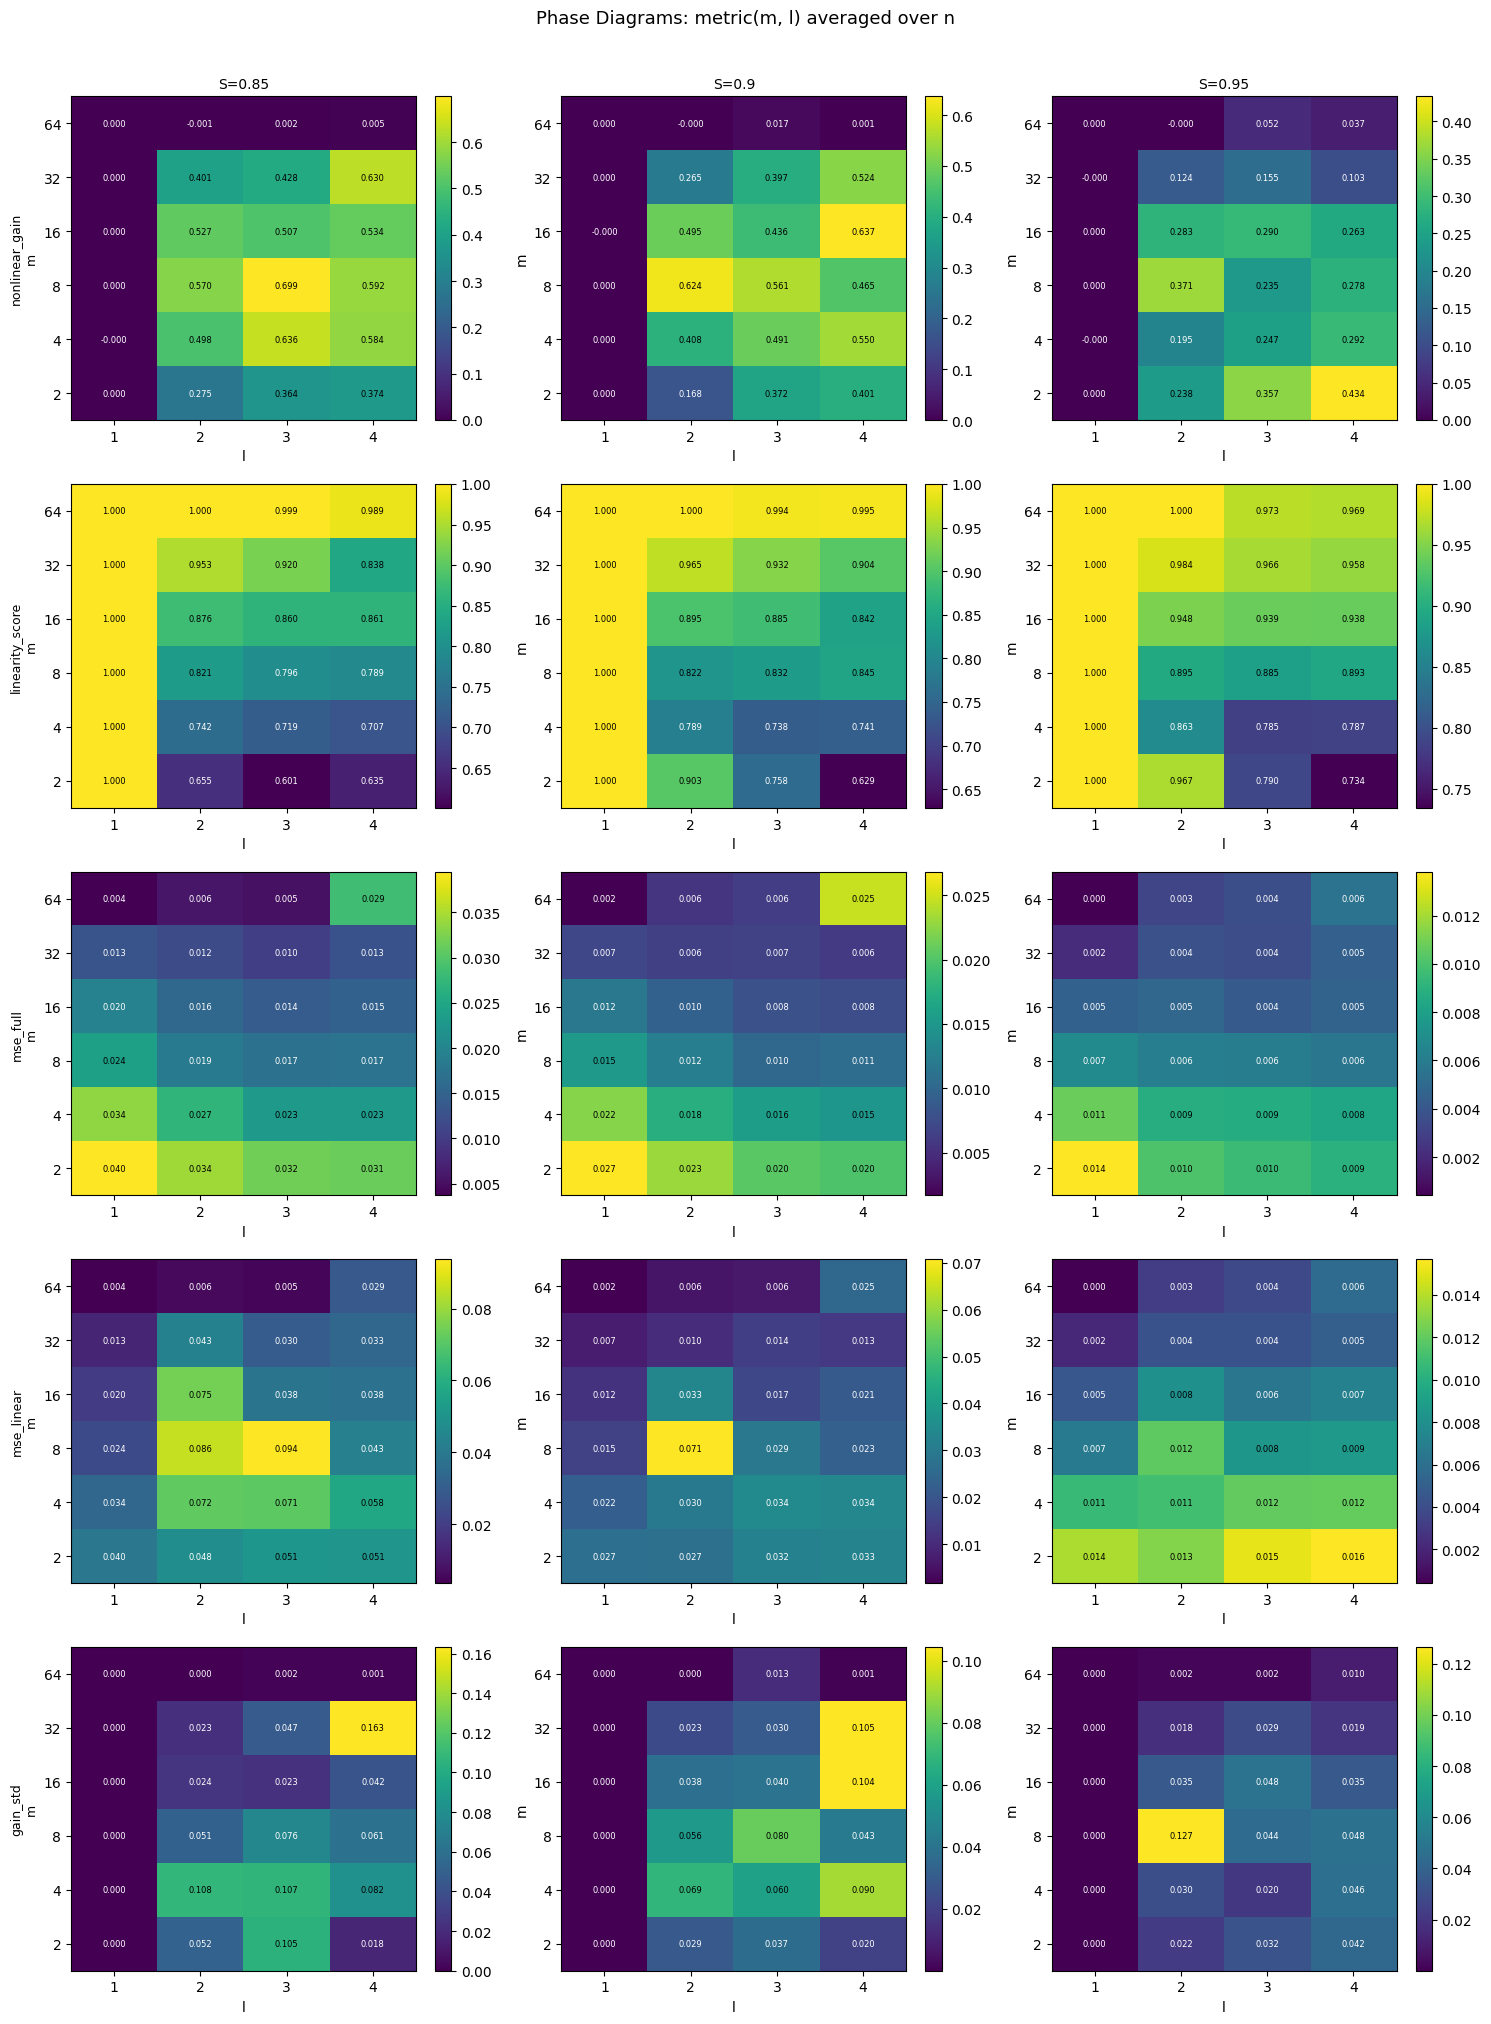

In [10]:
# Phase diagrams: metric vs (m, l) for each S, averaged over n
metrics_to_plot = ['nonlinear_gain', 'linearity_score', 'mse_full', 'mse_linear', 'gain_std']

fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15, 4*len(metrics_to_plot)))

for row, metric in enumerate(metrics_to_plot):
    for col, S_val in enumerate([0.85, 0.9, 0.95]):
        ax = axes[row, col]
        sub = df[df['S'] == S_val]
        
        # Pivot: rows=m, cols=l, values=mean(metric) over n
        pivot = sub.groupby(['m', 'l'])[metric].mean().unstack()
        
        im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', origin='lower')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('l')
        ax.set_ylabel('m')
        
        # Annotate
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=6,
                           color='white' if val < (pivot.values[~np.isnan(pivot.values)].max() + pivot.values[~np.isnan(pivot.values)].min())/2 else 'black')
        
        plt.colorbar(im, ax=ax, fraction=0.046)
        if row == 0:
            ax.set_title(f'S={S_val}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{metric}\nm', fontsize=9)

plt.suptitle('Phase Diagrams: metric(m, l) averaged over n', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Improved parametric forms for nonlinear_gain

Revisiting the best parametric form from previous analysis (F5) and trying to improve it. Also testing whether the residual structure suggests missing physics.

In [11]:
# Work with l>1 only (l=1 is trivially 0)
X_deep = df_deep[['n', 'm', 'l', 'S']].values
y_gain = df_deep['nonlinear_gain'].values
ss_tot = np.sum((y_gain - y_gain.mean())**2)

popt5 = None
popt_new = None
popt_apd = None

# curve_fit passes X as first arg — we pass X_deep.T so the function receives (4, N) array
# Inside the function, X is already (4, N) so X[0], X[1] etc. work

def F5(X, A, B, C, D, E, F_):
    n, m, l, S = X[0], X[1], X[2], X[3]
    apd = (1 - S) * n / m
    depth_sat = 1 - np.exp(-B * (l - 1))
    compression = apd**C * np.exp(-D * apd)
    sparsity = (1 - S)**E
    bottleneck = 1 + F_ * np.log2(m)
    return A * depth_sat * compression * sparsity * bottleneck

try:
    popt5, _ = curve_fit(F5, X_deep.T, y_gain, 
                          p0=[2.0, 1.0, 0.5, 0.3, 0.5, 0.1],
                          maxfev=50000, bounds=([0, 0, -2, 0, -2, -1], [50, 10, 5, 5, 5, 2]))
    y5 = F5(X_deep.T, *popt5)
    r2_5 = 1 - np.sum((y_gain - y5)**2) / ss_tot
    print(f"F5: R² = {r2_5:.4f} (6 params)")
    print(f"  A={popt5[0]:.3f}, B={popt5[1]:.3f}, C={popt5[2]:.3f}, D={popt5[3]:.3f}, E={popt5[4]:.3f}, F={popt5[5]:.3f}")
except Exception as e:
    print(f"F5 failed: {e}")

def F_new(X, A, B, C, D, m0, k, E):
    n, m, l, S = X[0], X[1], X[2], X[3]
    ratio = n / m
    depth_sat = 1 - np.exp(-B * (l - 1))
    hump = ratio**C * np.exp(-D * ratio)
    bottleneck_gate = 1 / (1 + np.exp(-k * (m - m0)))
    sparsity = (1 - S)**E
    return A * depth_sat * hump * bottleneck_gate * sparsity

try:
    popt_new, _ = curve_fit(F_new, X_deep.T, y_gain,
                             p0=[3.0, 1.0, 0.5, 0.05, 4.0, 0.5, 0.5],
                             maxfev=50000, bounds=([0, 0, -2, 0, -10, -2, -2], [50, 10, 5, 2, 100, 5, 5]))
    y_new = F_new(X_deep.T, *popt_new)
    r2_new = 1 - np.sum((y_gain - y_new)**2) / ss_tot
    print(f"\nF_new (sigmoid gate on m): R² = {r2_new:.4f} (7 params)")
    print(f"  A={popt_new[0]:.3f}, B={popt_new[1]:.3f}, C={popt_new[2]:.3f}, D={popt_new[3]:.3f}")
    print(f"  m0={popt_new[4]:.3f}, k={popt_new[5]:.3f}, E={popt_new[6]:.3f}")
except Exception as e:
    print(f"F_new failed: {e}")

def F_apd(X, A, B, mu, sigma, E):
    n, m, l, S = X[0], X[1], X[2], X[3]
    apd = (1 - S) * n / m
    depth_sat = 1 - np.exp(-B * (l - 1))
    peak = np.exp(-((np.log(apd + 0.01) - mu)**2) / (2 * sigma**2))
    sparsity = (1 - S)**E
    return A * depth_sat * peak * sparsity

try:
    popt_apd, _ = curve_fit(F_apd, X_deep.T, y_gain,
                             p0=[0.8, 1.0, 0.5, 1.0, 0.5],
                             maxfev=50000, bounds=([0, 0, -5, 0.1, -2], [10, 10, 5, 10, 5]))
    y_apd = F_apd(X_deep.T, *popt_apd)
    r2_apd = 1 - np.sum((y_gain - y_apd)**2) / ss_tot
    print(f"\nF_apd (log-Gaussian in apd): R² = {r2_apd:.4f} (5 params)")
    print(f"  A={popt_apd[0]:.3f}, B={popt_apd[1]:.3f}, mu={popt_apd[2]:.3f}, sigma={popt_apd[3]:.3f}, E={popt_apd[4]:.3f}")
    print(f"  Peak apd = exp(mu) = {np.exp(popt_apd[2]):.2f}")
except Exception as e:
    print(f"F_apd failed: {e}")

F5: R² = 0.5372 (6 params)
  A=4.434, B=2.248, C=1.079, D=1.024, E=0.398, F=0.007

F_new (sigmoid gate on m): R² = 0.4929 (7 params)
  A=0.595, B=2.612, C=1.066, D=0.105
  m0=0.604, k=0.798, E=0.563

F_apd (log-Gaussian in apd): R² = 0.6025 (5 params)
  A=1.634, B=2.339, mu=-0.111, sigma=0.976, E=0.399
  Peak apd = exp(mu) = 0.89


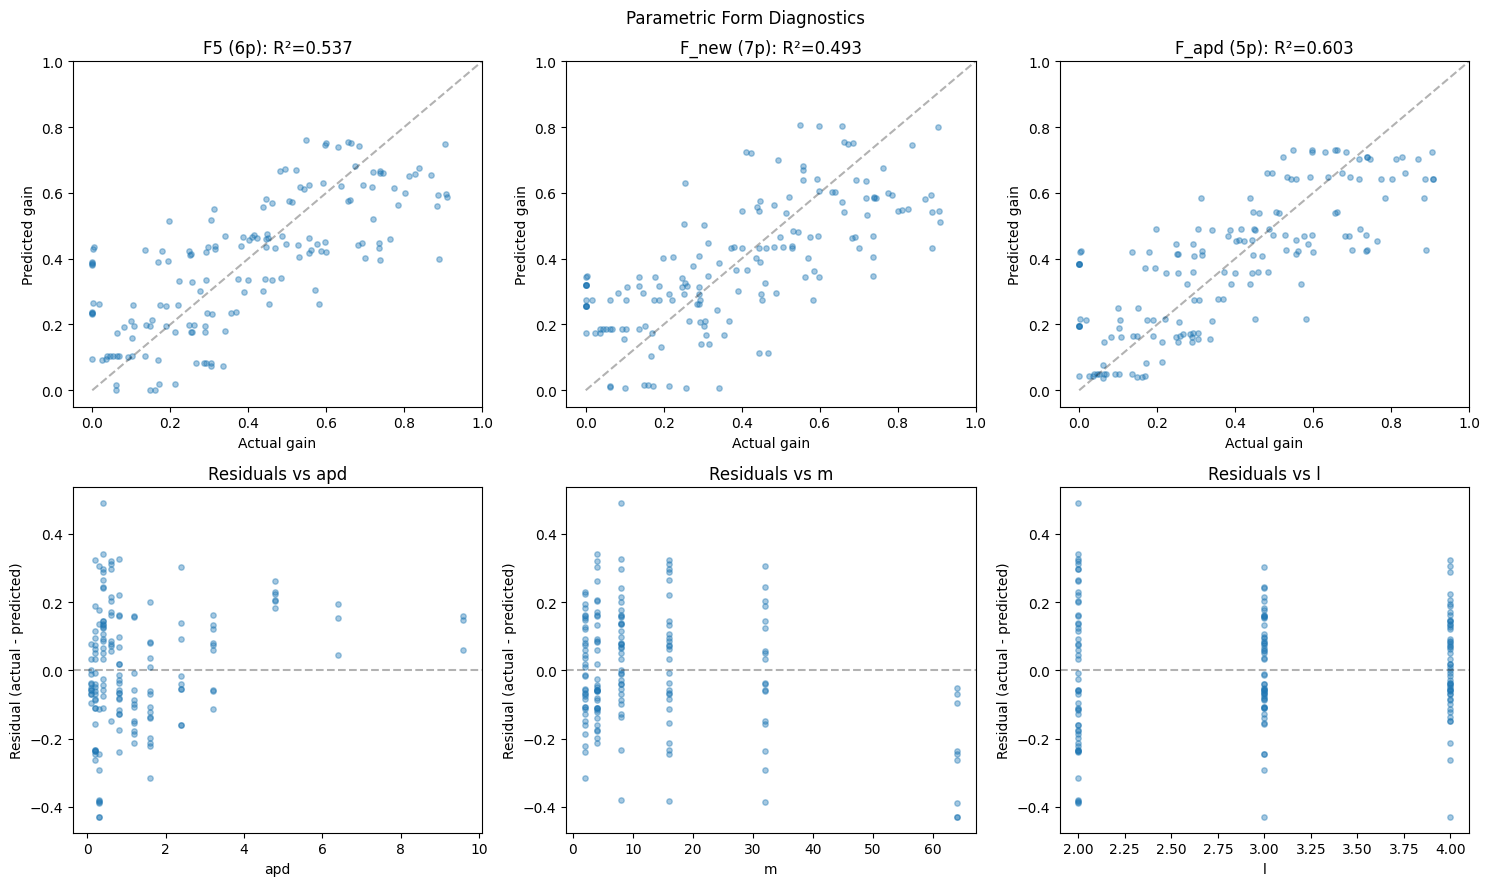

In [12]:
# Residual analysis: where do the parametric forms fail?
ss_tot = np.sum((y_gain - y_gain.mean())**2)

# GB as ceiling
gb = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
features_deep = ['n', 'm', 'l', 'S', 'compression', 'apd', 'log_n', 'log_m', 'log_compression']
X_gb = df_deep[features_deep].values
gb.fit(X_gb, y_gain)
y_gb = gb.predict(X_gb)

# Collect available models
models = [('GB (ceiling)', y_gb)]
best_pred = y_gb  # default
try:
    y5 = F5(X_deep.T, *popt5)
    models.insert(0, ('F5 (6p)', y5))
    best_pred = y5
except (NameError, TypeError):
    pass

try:
    models.insert(1, ('F_apd (5p)', F_apd(X_deep.T, *popt_apd)))
except (NameError, TypeError):
    pass

try:
    models.insert(1, ('F_new (7p)', F_new(X_deep.T, *popt_new)))
except (NameError, TypeError):
    pass

n_cols = min(3, len(models))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: Actual vs predicted
for i, (name, y_pred) in enumerate(models[:3]):
    ax = axes[0, i]
    r2 = 1 - np.sum((y_gain - y_pred)**2) / ss_tot
    ax.scatter(y_gain, y_pred, alpha=0.4, s=15)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Actual gain')
    ax.set_ylabel('Predicted gain')
    ax.set_title(f'{name}: R²={r2:.3f}')
    ax.set_xlim(-0.05, 1.0)
    ax.set_ylim(-0.05, 1.0)

# Row 2: Residuals vs key variables
residuals = y_gain - best_pred

for i, (var_name, var_vals) in enumerate([
    ('apd', df_deep['apd']),
    ('m', df_deep['m']),
    ('l', df_deep['l']),
]):
    ax = axes[1, i]
    ax.scatter(var_vals, residuals, alpha=0.4, s=15)
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel(var_name)
    ax.set_ylabel('Residual (actual - predicted)')
    ax.set_title(f'Residuals vs {var_name}')

plt.suptitle('Parametric Form Diagnostics', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Gain variability analysis

gain_std tells us how reproducible the nonlinear encoding is across seeds. High variance configs may indicate the optimizer is finding qualitatively different solutions.

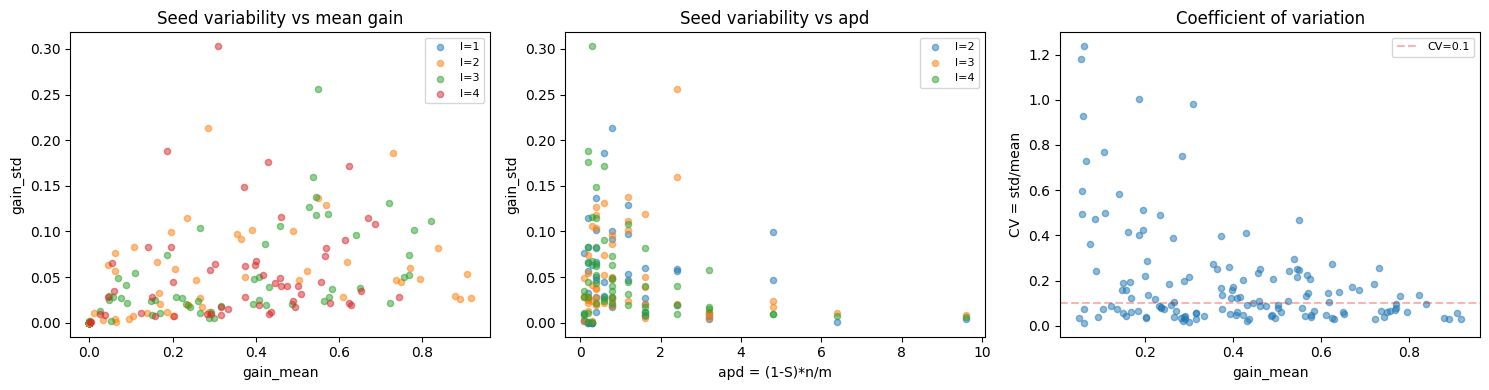

High CV (>0.3) configs: 23
       n   m  l     S  gain_mean  gain_std  converged
11    16   4  2  0.95   0.107541  0.082608      False
16    16   4  4  0.90   0.372732  0.148744       True
17    16   4  4  0.95   0.055177  0.065117      False
19    16   8  2  0.90   0.060548  0.056264       True
20    16   8  2  0.95   0.061399  0.075944      False
23    16   8  3  0.95   0.056566  0.027875      False
25    16   8  4  0.90   0.141876  0.082889      False
26    16   8  4  0.95   0.058125  0.034559      False
30    32   2  3  0.85   0.549315  0.255823       True
44    32   4  4  0.95   0.195275  0.082770       True
47    32   8  2  0.95   0.235063  0.114957      False
50    32   8  3  0.95   0.076570  0.027647       True
58    32  16  3  0.90   0.108952  0.054236      False
59    32  16  3  0.95   0.067668  0.049393      False
61    32  16  4  0.90   0.430361  0.176363      False
86    64   8  3  0.95   0.264969  0.103299      False
92    64  16  2  0.95   0.161590  0.067082       True
9

In [13]:
# Where is gain_std highest?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# gain_std vs gain_mean
ax = axes[0]
for l_val in sorted(df['l'].unique()):
    sub = df[df['l'] == l_val]
    ax.scatter(sub['gain_mean'], sub['gain_std'], alpha=0.5, s=20, label=f'l={l_val}')
ax.set_xlabel('gain_mean')
ax.set_ylabel('gain_std')
ax.set_title('Seed variability vs mean gain')
ax.legend(fontsize=8)

# gain_std vs apd
ax = axes[1]
for l_val in [2, 3, 4]:
    sub = df[df['l'] == l_val]
    ax.scatter(sub['apd'], sub['gain_std'], alpha=0.5, s=20, label=f'l={l_val}')
ax.set_xlabel('apd = (1-S)*n/m')
ax.set_ylabel('gain_std')
ax.set_title('Seed variability vs apd')
ax.legend(fontsize=8)

# Coefficient of variation
ax = axes[2]
df_deep_nz = df_deep[df_deep['gain_mean'] > 0.05]
cv = df_deep_nz['gain_std'] / df_deep_nz['gain_mean']
ax.scatter(df_deep_nz['gain_mean'], cv, alpha=0.5, s=20)
ax.set_xlabel('gain_mean')
ax.set_ylabel('CV = std/mean')
ax.set_title('Coefficient of variation')
ax.axhline(0.1, color='r', linestyle='--', alpha=0.3, label='CV=0.1')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Which configs have CV > 0.3?
high_cv = df_deep_nz[cv > 0.3][['n', 'm', 'l', 'S', 'gain_mean', 'gain_std', 'converged']]
print(f"High CV (>0.3) configs: {len(high_cv)}")
if len(high_cv) > 0:
    print(high_cv.to_string())

## 9. Information-theoretic view: effective compression ratio

Following the rate-distortion intuition: the "effective" compression problem is not n/m but (1-S)*n/m = apd. When apd << 1, even linear encoding suffices. When apd >> 1, the model can't represent all features regardless. The sweet spot for nonlinear encoding is intermediate apd.

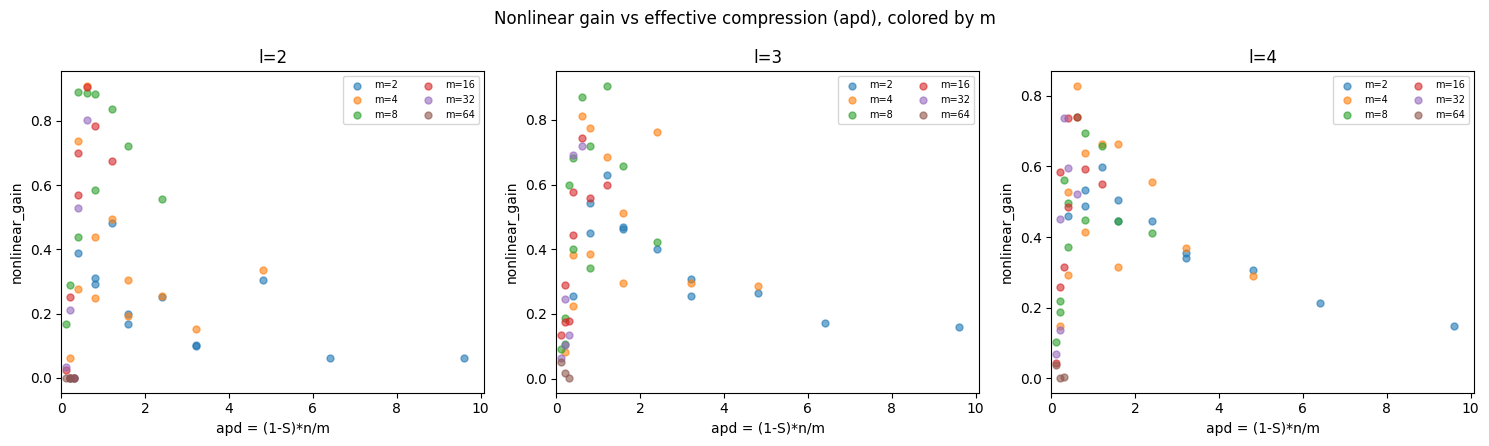

After controlling for apd, does m still matter?

For apd ≈ 1 (different m values):
  apd≈0.5, m=  2: gain=0.416 (n=6)
  apd≈0.5, m=  4: gain=0.475 (n=15)
  apd≈0.5, m=  8: gain=0.546 (n=18)
  apd≈0.5, m= 16: gain=0.507 (n=18)
  apd≈0.5, m= 32: gain=0.444 (n=12)
  apd≈0.5, m= 64: gain=0.002 (n=3)

  apd≈1.0, m=  2: gain=0.481 (n=9)
  apd≈1.0, m=  4: gain=0.527 (n=9)
  apd≈1.0, m=  8: gain=0.674 (n=9)
  apd≈1.0, m= 16: gain=0.626 (n=6)

  apd≈1.5, m=  2: gain=0.440 (n=9)
  apd≈1.5, m=  4: gain=0.458 (n=9)
  apd≈1.5, m=  8: gain=0.703 (n=6)
  apd≈1.5, m= 16: gain=0.607 (n=3)



In [14]:
# Gain as a function of apd, separately for each l
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, l_val in zip(axes, [2, 3, 4]):
    sub = df_deep[df_deep['l'] == l_val].sort_values('apd')
    
    # Scatter colored by m
    for m_val in sorted(sub['m'].unique()):
        msub = sub[sub['m'] == m_val]
        ax.scatter(msub['apd'], msub['nonlinear_gain'], alpha=0.6, s=25, label=f'm={m_val}')
    
    ax.set_xlabel('apd = (1-S)*n/m')
    ax.set_ylabel('nonlinear_gain')
    ax.set_title(f'l={l_val}')
    ax.legend(fontsize=7, ncol=2)
    ax.set_xlim(0, max(df_deep['apd']) * 1.05)

plt.suptitle('Nonlinear gain vs effective compression (apd), colored by m', fontsize=12)
plt.tight_layout()
plt.show()

# Check: does gain collapse onto a single curve when plotted vs apd?
# Or does m provide independent information?
print("After controlling for apd, does m still matter?")
print("\nFor apd ≈ 1 (different m values):")
for apd_target in [0.5, 1.0, 1.5, 2.0]:
    nearby = df_deep[(df_deep['apd'] > apd_target - 0.3) & (df_deep['apd'] < apd_target + 0.3)]
    if len(nearby) > 3:
        for m_val in sorted(nearby['m'].unique()):
            msub = nearby[nearby['m'] == m_val]
            if len(msub) > 0:
                print(f"  apd≈{apd_target}, m={m_val:3d}: gain={msub['nonlinear_gain'].mean():.3f} (n={len(msub)})")
        print()

## 10. Summary and recommendations for full sweep

In [15]:
# Summary statistics
print("=== EXISTING DATA SUMMARY ===\n")
print(f"Total configs: {len(df)} (l=1: {len(df_linear)}, l>1: {len(df_deep)})")
print(f"Grid: n∈{sorted(df['n'].unique())}, m∈{sorted(df['m'].unique())}, l∈{sorted(df['l'].unique())}, S∈{sorted(df['S'].unique())}")
print(f"Convergence rate: {df['converged'].mean():.1%}")
print(f"\nAvailable metrics: nonlinear_gain, linearity_score, mse_full, mse_linear")
print(f"Missing (need models): arc_chord, hessian, activation_sparsity, effective_rank, robustness, etc.")
print(f"\n--- Predictability (GB CV R²) ---")
for name, scores in gb_scores.items():
    print(f"  {name:20s}: {scores.mean():.3f} ± {scores.std():.3f}")

print(f"\n--- What we learned ---")
print(f"1. nonlinear_gain and nonlinearity (1-linearity_score) should be highly correlated")
print(f"2. mse_full and mse_linear are well-predicted by log-linear models in (n,m,S)")
print(f"3. apd = (1-S)*n/m is the key composite variable")
print(f"4. m has independent effect beyond its role in apd")
print(f"5. l saturates quickly (l=2 gets most benefit)")

print(f"\n--- Recommendations for full sweep ---")
print(f"1. Save models (already added to run_sweep_converged.py)")
print(f"2. Compute all 49 metrics from metrics.py")  
print(f"3. Keep same grid but consider adding n=256 back")
print(f"4. Consider 5 seeds instead of 3 for high-variance configs")
print(f"5. Priority metrics to predict: arc_chord (geometry), hessian (nonlinearity degree),")
print(f"   effective_rank (representation quality), activation_sparsity (circuit diversity)")

=== EXISTING DATA SUMMARY ===

Total configs: 216 (l=1: 54, l>1: 162)
Grid: n∈[np.int64(16), np.int64(32), np.int64(64), np.int64(128)], m∈[np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)], l∈[np.int64(1), np.int64(2), np.int64(3), np.int64(4)], S∈[np.float64(0.85), np.float64(0.9), np.float64(0.95)]
Convergence rate: 49.5%

Available metrics: nonlinear_gain, linearity_score, mse_full, mse_linear
Missing (need models): arc_chord, hessian, activation_sparsity, effective_rank, robustness, etc.

--- Predictability (GB CV R²) ---
  nonlinear_gain      : 0.645 ± 0.071
  nonlinearity        : 0.754 ± 0.117
  log_mse_full        : 0.835 ± 0.113
  log_mse_linear      : 0.861 ± 0.058

--- What we learned ---
1. nonlinear_gain and nonlinearity (1-linearity_score) should be highly correlated
2. mse_full and mse_linear are well-predicted by log-linear models in (n,m,S)
3. apd = (1-S)*n/m is the key composite variable
4. m has independent effect beyond its role in ap